In [76]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import spectral
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score,cohen_kappa_score,accuracy_score
from scipy.io import loadmat
import os
%matplotlib inline

In [77]:
##hypeperameters and experimental settings
RANDOM_SEED=666
DATASET = 'IP'    ## IP  SA  LK  BO
TRAIN_RATE = 0.05  ## ratio of training data
VAL_RATE = 0.05    ## ratio of valuating data
EPOCH = 200    ##number of teacher epoch
VAL_EPOCH = 1  ##interval of valuation
LR = 0.001    ##learning rate
WEIGHT_DECAY = 1e-3
BATCH_SIZE = 64
N_PCA = 64
DEVICE = 0  ##-1:CPU  0:cuda 0
PATCH_SIZE = 13
NHEADS = 8
FEEDFORWARD_FACTOR = 4
NUM_LAYERS = 3
SAVE_PATH = f"results\\{DATASET}"
if not os.path.isdir(SAVE_PATH):
    os.mkdir(SAVE_PATH)

In [78]:
## Set random seed for reproduction
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG']=':4096:8'
torch.use_deterministic_algorithms(True)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED) # if you are using multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [79]:
def loadData(name):
    data_path = os.path.join(os.getcwd(),'dataset')
    if name == 'IP':
        data = loadmat(os.path.join(data_path, 'IndianPines\\Indian_pines_corrected.mat'))['indian_pines_corrected']
        labels = loadmat(os.path.join(data_path, 'IndianPines\\Indian_pines_gt.mat'))['indian_pines_gt']
        class_name = [ "Alfalfa", "Corn-notill", "Corn-mintill","Corn", "Grass-pasture", 
                       "Grass-trees","Grass-pasture-mowed", "Hay-windrowed", "Oats","Soybean-notill", "Soybean-mintill", "Soybean-clean","Wheat", "Woods", "Buildings-Grass-Trees-Drives","Stone-Steel-Towers"]
    elif name == 'SA':
        data = loadmat(os.path.join(data_path, 'Salinas\\Salinas_corrected.mat'))['salinas_corrected']
        labels = loadmat(os.path.join(data_path, 'Salinas\\Salinas_gt.mat'))['salinas_gt']
        class_name = ['Brocoli_green_weeds_1','Brocoli_green_weeds_2','Fallow',
                        'Fallow_rough_plow','Fallow_smooth','Stubble','Celery','Grapes_untrained','Soil_vinyard_develop','Corn_senesced_green','Lettuce_romaine_4wk','Lettuce_romaine_5wk','Lettuce_romaine_6wk','Lettuce_romaine_7wk','Vinyard_untrained','Vinyard_vertical']
    elif name == 'LK':
        data = loadmat(os.path.join(data_path, 'WHU_Hi_LongKou\\WHU_Hi_LongKou.mat'))['WHU_Hi_LongKou']
        labels = loadmat(os.path.join(data_path, 'WHU_Hi_LongKou\\WHU_Hi_LongKou_gt.mat'))['WHU_Hi_LongKou_gt']
        class_name = ['Corn', 'Cotton', 'Sesame', 'Broad-leaf soybean','Narrow-leaf soybean', 'Rice', 
                      'Water','Roads and houses', 'Mixed weed'] 
    elif name == 'BO':
        data = loadmat(os.path.join(data_path, 'Botswana\\Botswana.mat'))['Botswana']
        labels = loadmat(os.path.join(data_path, 'Botswana\\Botswana_gt.mat'))['Botswana_gt']
        class_name = ['Water','Hippo grass','Hippo grass 1','Hippo grass 2','Reeds','Riparian','Firescar','Island interior','Acacia woodlands',
                      'Acacia shrublands','Acacia grasslands','Short mopanc','Mixed mopanc','Chalcedony']
    return data, labels, class_name

In [80]:
def applyPCA(X, numComponents=15):
    """PCA processing

    Args:
        X (ndarray M*N*C): data needs DR
        numComponents (int, optional): number of reserved components. Defaults to 15.

    Returns:
        newX: _description_
    """
    newX = np.reshape(X, (-1, X.shape[2]))
    pca = PCA(n_components=numComponents, whiten=True)   ##PCA and normalization
    newX = pca.fit_transform(newX)
    newX = np.reshape(newX, (X.shape[0],X.shape[1], numComponents))
    return newX

In [81]:
def sample_gt(gt, train_rate, seed):
    """ generate training gt for training dataset
    Args:
        gt (ndarray): full classmap
        train_rate (float): ratio of training dataset
    Returns:
        train_gt(ndarray): classmap of training data
        test_gt(ndarray): classmap of test data
    """
    indices = np.nonzero(gt)  ##([x1,x2,...],[y1,y2,...])
    X = list(zip(*indices))  ## X=[(x1,y1),(x2,y2),...] location of pixels
    y = gt[indices].ravel()
    train_gt = np.zeros_like(gt)
    test_gt = np.zeros_like(gt)
    if train_rate > 1:
       train_rate = int(train_rate)
    train_indices, test_indices = train_test_split(X, train_size=train_rate, stratify=y, random_state=seed)
    train_indices = [t for t in zip(*train_indices)]   ##[[x1,x2,...],[y1,y2,...]]
    test_indices = [t for t in zip(*test_indices)]
    train_gt[tuple(train_indices)] = gt[tuple(train_indices)]
    test_gt[tuple(test_indices)] = gt[tuple(test_indices)]
    
    return train_gt, test_gt

In [82]:
class PatchSet(Dataset):
    """ Generate 3D patch from hyperspectral dataset """
    def __init__(self, data, pca_data, gt, patch_size, is_pred=False):
        """
        Args:
            data: 3D hyperspectral image
            pca_data: 3D hyperspectral image after pca
            gt: 2D array of labels
            patch_size: int, size of the 3D patch
            is_pred: bool, create data without label for prediction (default False) 
        """
        super(PatchSet, self).__init__()
        self.is_pred = is_pred
        self.patch_size = patch_size
        p = self.patch_size // 2
        self.data = np.pad(data,((p,p),(p,p),(0,0)),'constant',constant_values = 0)
        self.pca_data = np.pad(pca_data,((p,p),(p,p),(0,0)),'constant',constant_values = 0)
        if is_pred:
            gt = np.ones_like(gt)
        self.label = np.pad(gt,(p,p),'constant',constant_values = 0)
        x_pos, y_pos = np.nonzero(gt)
        x_pos, y_pos = x_pos + p, y_pos + p   ##indices after padding
        self.indices = np.array([(x,y) for x,y in zip(x_pos, y_pos)])
        if not is_pred:
            np.random.shuffle(self.indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.indices[i]
        x1, y1 = x - self.patch_size // 2, y - self.patch_size // 2
        x2, y2 = x1 + self.patch_size, y1 + self.patch_size
        data = self.data[x1:x2, y1:y2]
        pca_data = self.pca_data[x1:x2, y1:y2]
        label = self.label[x, y]
        data = np.asarray(data, dtype='float32').transpose((2, 0, 1))
        pca_data = np.asarray(pca_data, dtype='float32').transpose((2, 0, 1))
        label = np.asarray(label, dtype='int64')
        data = torch.from_numpy(data)
        pca_data = torch.from_numpy(pca_data)
        label = torch.from_numpy(label)
        if self.is_pred:
            return data, pca_data
        else: return data, pca_data, label

In [83]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool3d(1)  
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()  
        )

    def forward(self, x):
        b, c, d, h, w = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1, 1) 
        x = x * y
        return x

In [84]:
class ChanLayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps                                   
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))   
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))  

    def forward(self, x):
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)  
        mean = torch.mean(x, dim=1, keepdim=True)                
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b

In [85]:
class PixelViT(nn.Module):
    def __init__(self, bands):
        super().__init__()
        self.layernorm1 = nn.LayerNorm(bands)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=bands,                            
            nhead=NHEADS,                          
            dim_feedforward=FEEDFORWARD_FACTOR*bands, 
            batch_first=True,                  
            dropout=0.4,
        )
        self.attn = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS) 
        self.layernorm2 = nn.LayerNorm(bands)

    def forward(self, x):
        x = self.layernorm1(x)
        x = self.attn(x)  
        x = self.layernorm2(x)
        out = x.mean(dim=1)  
        return out

In [86]:
class S3ViT(nn.Module):
    def __init__(self, in_chs, patch_size, class_nums):
        super().__init__()
        self.in_chs = in_chs
        self.patch_size = patch_size
        self.num_blocks = 4

        self.channelnorm = ChanLayerNorm(in_chs)
        self.avg_pool = nn.AdaptiveAvgPool3d(1) 
        self.layernorm = nn.LayerNorm(320)

        self.conv1 = nn.Sequential(
                    nn.Conv2d(in_channels=in_chs,out_channels=256,kernel_size=1),
                    nn.BatchNorm2d(256),
                    nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(
                    nn.Conv3d(in_channels=1,out_channels=8,kernel_size=(17, 1, 1), stride=(4, 1, 1)),
                    nn.BatchNorm3d(8),
                    nn.ReLU(inplace=True))
        self.conv3 = nn.Sequential(
                    nn.Conv3d(in_channels=8,out_channels=16,kernel_size=(7, 3, 3)),
                    nn.BatchNorm3d(16),
                    nn.ReLU(inplace=True))
        self.conv4 = nn.Sequential(
                    nn.Conv3d(in_channels=16,out_channels=32,kernel_size=(7, 3, 3)),
                    nn.BatchNorm3d(32),
                    nn.ReLU(inplace=True))
        self.conv5 = nn.Sequential(
                    nn.Conv3d(in_channels=32,out_channels=64,kernel_size=(3, 3, 3)),
                    nn.BatchNorm3d(64),
                    nn.ReLU(inplace=True))

        self.se3 = SELayer(channel=64*self.num_blocks, reduction=16)
        self.pixel_vit = PixelViT(bands=64)
        self.fc = nn.Linear(320, class_nums) 

    def forward(self, X, Y):
        # CNN Branch
        x = self.channelnorm(X)
        x = self.conv1(x)
        x = x.unsqueeze(1)
        x = self.conv2(x)
        blocks = []
        for i in range(self.num_blocks):
            block = x[:, :, i*15:(i+1)*15, :, :]
            block = self.conv3(block)
            block = self.conv4(block)
            block = self.conv5(block)
            blocks.append(block)
        merged = torch.cat(blocks, dim=1) 
        merged = self.se3(merged)
        B, C, D, H, W = merged.shape
        cnn = self.avg_pool(merged).view(B, C)

        # ViT Branch
        B, C, H, W = Y.shape
        y = Y.reshape(B, C, -1).permute(0, 2, 1)  
        vit = self.pixel_vit(y)  

        # feature fusion
        combined_features = torch.cat((cnn, vit), dim=1)
        combined_features = self.layernorm(combined_features)
        out = self.fc(combined_features) 
        return out

In [87]:
def train(model, train_loader, val_loader, save_path, device):
    loss_list = []
    acc_list = []
    val_acc_list = []
    val_epoch_list = []

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), LR, weight_decay=WEIGHT_DECAY)
    loss_func = nn.CrossEntropyLoss()
    train_num = train_loader.dataset.__len__()
    val_num = val_loader.dataset.__len__()

    fig = plt.figure()
    ax1 = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 1, 2)
    try:
        for e in range(EPOCH):
            model.train()
            avg_loss = 0.
            train_acc = 0
            for batch_idx, (data, pca_data, target) in enumerate(train_loader):
                data,pca_data,target = data.to(device),pca_data.to(device),target.to(device)
                optimizer.zero_grad()
                out = model(data,pca_data)
                target = target - 1  ## class 0 in out is class 1 in target
                loss = loss_func(out,target)
                loss.backward()
                optimizer.step()
                avg_loss += loss.item()
                _,pred = torch.max(out,dim=1)
                train_acc += (pred == target).sum().item()
            loss_list.append(avg_loss/train_num)
            acc_list.append(train_acc/train_num)
            print(f"epoch {e}/{EPOCH} loss:{loss_list[e]}  acc:{acc_list[e]}")
            ## valuation
            if (e+1)%VAL_EPOCH == 0 or (e+1)==EPOCH:
                val_acc =0
                model.eval()
                for batch_idx, (data, pca_data, target) in enumerate(val_loader):
                    data,pca_data,target = data.to(device),pca_data.to(device),target.to(device)
                    out = model(data,pca_data)
                    target = target - 1  ## class 0 in out is class 1 in target
                    _,pred = torch.max(out,dim=1)
                    val_acc += (pred == target).sum().item()
                val_acc_list.append(val_acc/val_num)
                val_epoch_list.append(e)
                print(f"epoch {e}/{EPOCH}  val_acc:{val_acc_list[-1]}")
                save_name = os.path.join(save_path, f"epoch_{e}_acc_{val_acc_list[-1]:.4f}.pth")
                torch.save(model.state_dict(),save_name)
        ax1.plot(np.arange(e+1),loss_list)
        ax1.set_title('loss')
        ax1.set_xlabel('epoch')
        ax2.plot(np.arange(e+1),acc_list,label = 'train_acc')
        ax2.plot(val_epoch_list,val_acc_list,label = 'val_acc')
        ax2.set_title('acc')
        ax2.set_xlabel('epoch')
        ax2.legend()
    except Exception as exc:
        print(exc)
    finally:
        print(f'Stop in epoch {e}')

    return val_acc_list, val_epoch_list

In [88]:
def test(best_model, label, all_loader, test_gt, run_idx, device):
    best_model.to(device)
    best_model.eval()
    pred_map = []
    for batch_idx, (data, pca_data) in enumerate(all_loader):
        data = data.to(device)
        pca_data = pca_data.to(device)
        target = best_model(data, pca_data)
        _, pred = torch.max(target, dim=1)
        pred_map += [np.array(pred.detach().cpu() + 1)]  ## class 0 in pred_map is class 1 in gt
    pred_map = np.asarray(np.hstack(pred_map), dtype=np.uint8).reshape(label.shape[0], label.shape[1])

    spectral.save_rgb(os.path.join(SAVE_PATH,f"prediction_run{run_idx}.jpg"),pred_map*(label!=0),colors = spectral.spy_colors)
    spectral.imshow(classes=pred_map*(label!=0), title='prediction', figsize=(7, 7))
    plt.show()

    test_pred = pred_map[test_gt != 0]
    test_true = test_gt[test_gt != 0]

    return test_pred, test_true

In [89]:
## get best model path and del other models
def get_best_model(acc_list, epoch_list, save_path):
    """get best model path by valuation list

    Args:
        acc_list (list): list of valuation accuracy
        epoch_list (list): list of valuation epoch
        save_path (str): path of save dir

    Returns:
        best_model_path: path of best model
    """
    acc_list = np.array(acc_list)
    epoch_list = np.array(epoch_list)
    best_index = np.argwhere(acc_list==np.max(acc_list))[-1].item()
    best_epoch = epoch_list[best_index]
    best_acc = acc_list[best_index]
    file_name = f"epoch_{best_epoch}_acc_{best_acc:.4f}.pth"
    best_model_path=os.path.join(save_path, file_name)
    print(f"best model:{file_name}")
    ##del save model except best model
    for f in os.listdir(save_path):
        if f[-3:]=='pth' and os.path.join(save_path,f)!=best_model_path:
            os.remove(os.path.join(save_path,f))
    return best_model_path

run 1 / 10
  class   train_num  val_num   test_num   total   
    1         2         2         42        46    
    2         71        71       1286      1428   
    3         41        42       747       830    
    4         12        12       213       237    
    5         24        24       435       483    
    6         37        36       657       730    
    7         1         1         26        28    
    8         24        24       430       478    
    9         1         1         18        20    
    10        49        49       874       972    
    11       123       123       2209      2455   
    12        30        30       533       593    
    13        10        10       185       205    
    14        63        63       1139      1265   
    15        19        19       348       386    
    16        5         5         83        93    
  total      512       512       9225     10249   
Layer (type (var_name))                                      Param #   

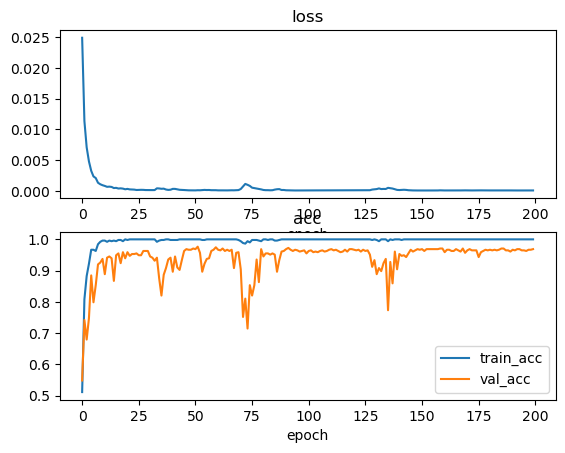

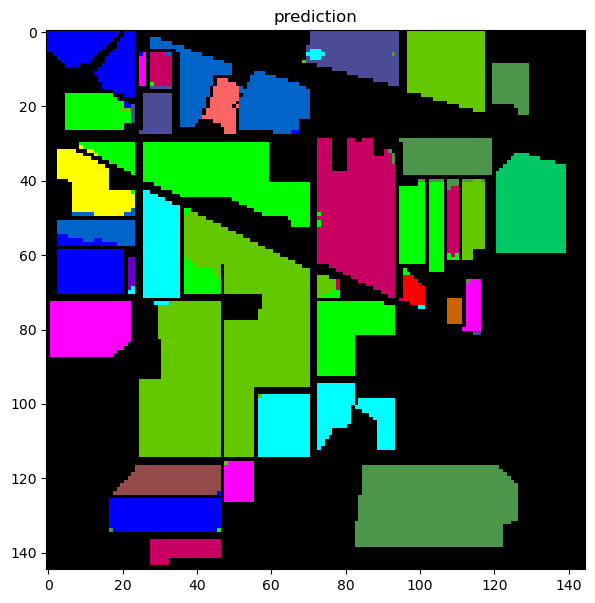

run 2 / 10
epoch 0/200 loss:0.02522709802724421  acc:0.52734375
epoch 0/200  val_acc:0.5078125
epoch 1/200 loss:0.011443378054536879  acc:0.81640625
epoch 1/200  val_acc:0.626953125
epoch 2/200 loss:0.007096276152879  acc:0.876953125
epoch 2/200  val_acc:0.6875
epoch 3/200 loss:0.004877823375863954  acc:0.931640625
epoch 3/200  val_acc:0.8828125
epoch 4/200 loss:0.003114066508715041  acc:0.953125
epoch 4/200  val_acc:0.84765625
epoch 5/200 loss:0.0024867560277925804  acc:0.95703125
epoch 5/200  val_acc:0.8984375
epoch 6/200 loss:0.0017634818505030125  acc:0.982421875
epoch 6/200  val_acc:0.818359375
epoch 7/200 loss:0.0014500386314466596  acc:0.986328125
epoch 7/200  val_acc:0.791015625
epoch 8/200 loss:0.0012729706722893752  acc:0.982421875
epoch 8/200  val_acc:0.8359375
epoch 9/200 loss:0.0009618953554308973  acc:0.990234375
epoch 9/200  val_acc:0.865234375
epoch 10/200 loss:0.0006497170688817278  acc:0.998046875
epoch 10/200  val_acc:0.9375
epoch 11/200 loss:0.0006603348738281056  a

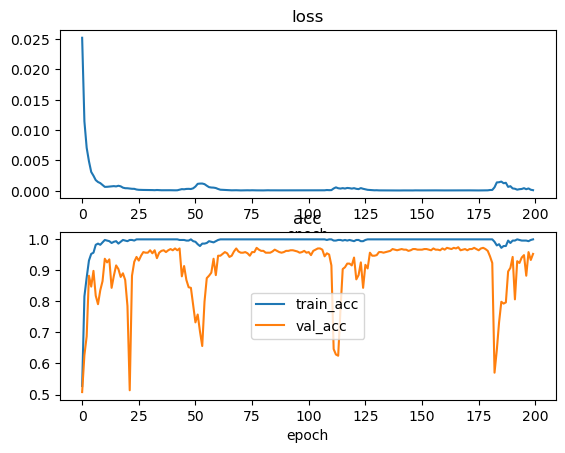

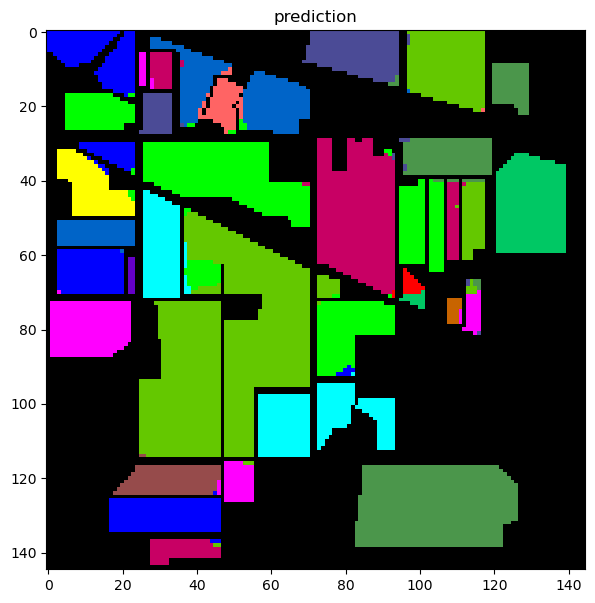

run 3 / 10
epoch 0/200 loss:0.024089606245979667  acc:0.533203125
epoch 0/200  val_acc:0.43359375
epoch 1/200 loss:0.011995526612736285  acc:0.783203125
epoch 1/200  val_acc:0.46875
epoch 2/200 loss:0.007233389711473137  acc:0.87890625
epoch 2/200  val_acc:0.78515625
epoch 3/200 loss:0.004761009011417627  acc:0.9296875
epoch 3/200  val_acc:0.833984375
epoch 4/200 loss:0.0033928277262020856  acc:0.94921875
epoch 4/200  val_acc:0.90234375
epoch 5/200 loss:0.002597506914753467  acc:0.970703125
epoch 5/200  val_acc:0.859375
epoch 6/200 loss:0.001723596957162954  acc:0.982421875
epoch 6/200  val_acc:0.79296875
epoch 7/200 loss:0.0015107987492228858  acc:0.986328125
epoch 7/200  val_acc:0.876953125
epoch 8/200 loss:0.001269175874767825  acc:0.986328125
epoch 8/200  val_acc:0.85546875
epoch 9/200 loss:0.001075256303010974  acc:0.982421875
epoch 9/200  val_acc:0.927734375
epoch 10/200 loss:0.0007063594748615287  acc:0.99609375
epoch 10/200  val_acc:0.947265625
epoch 11/200 loss:0.0005786125257

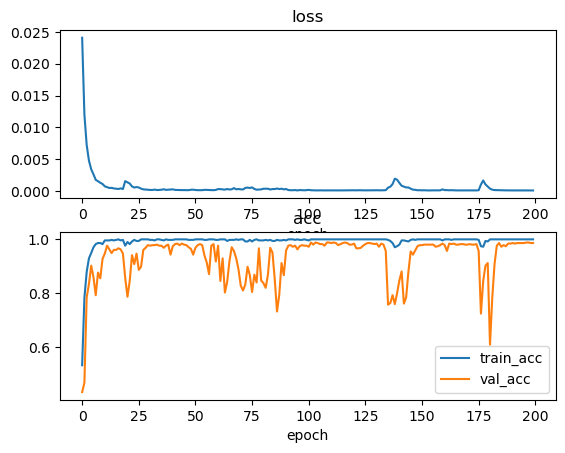

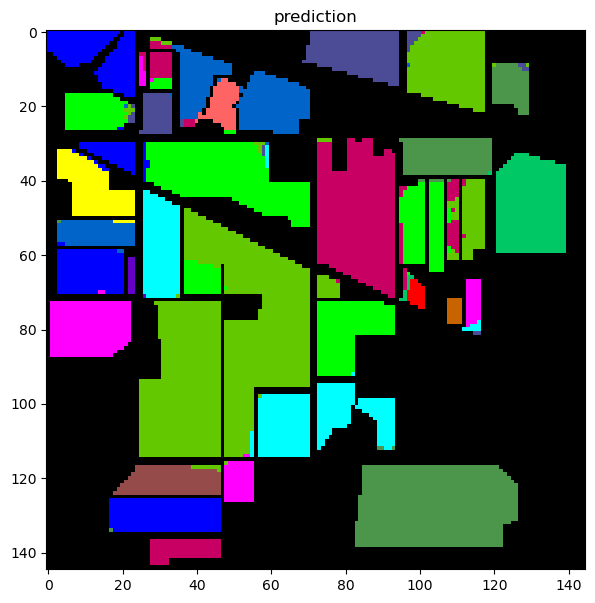

run 4 / 10
epoch 0/200 loss:0.023788915714249015  acc:0.533203125
epoch 0/200  val_acc:0.443359375
epoch 1/200 loss:0.011263403110206127  acc:0.80859375
epoch 1/200  val_acc:0.677734375
epoch 2/200 loss:0.006568101060111076  acc:0.904296875
epoch 2/200  val_acc:0.759765625
epoch 3/200 loss:0.003868913045153022  acc:0.9609375
epoch 3/200  val_acc:0.818359375
epoch 4/200 loss:0.0028359128773445264  acc:0.96484375
epoch 4/200  val_acc:0.892578125
epoch 5/200 loss:0.0018166898225899786  acc:0.978515625
epoch 5/200  val_acc:0.857421875
epoch 6/200 loss:0.001151474098151084  acc:0.9921875
epoch 6/200  val_acc:0.919921875
epoch 7/200 loss:0.0009907834464684129  acc:0.994140625
epoch 7/200  val_acc:0.796875
epoch 8/200 loss:0.0007163641821534839  acc:1.0
epoch 8/200  val_acc:0.869140625
epoch 9/200 loss:0.0005760869062214624  acc:0.998046875
epoch 9/200  val_acc:0.87890625
epoch 10/200 loss:0.0004951169903506525  acc:1.0
epoch 10/200  val_acc:0.853515625
epoch 11/200 loss:0.0003912529427907429

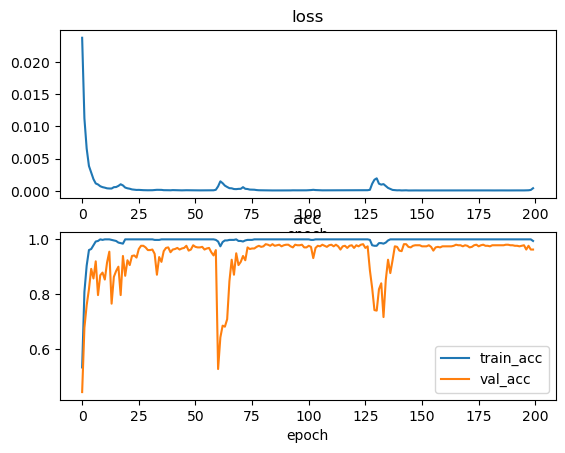

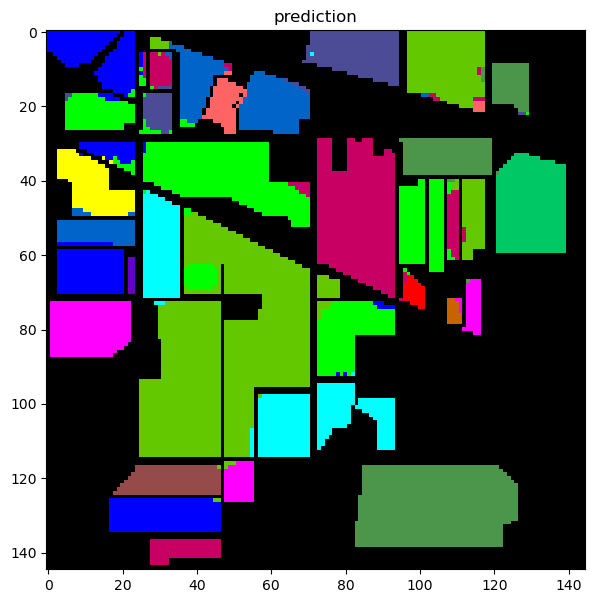

run 5 / 10
epoch 0/200 loss:0.025550785241648555  acc:0.48828125
epoch 0/200  val_acc:0.421875
epoch 1/200 loss:0.011779145104810596  acc:0.810546875
epoch 1/200  val_acc:0.640625
epoch 2/200 loss:0.007239298371132463  acc:0.884765625
epoch 2/200  val_acc:0.7578125
epoch 3/200 loss:0.005150850454811007  acc:0.93359375
epoch 3/200  val_acc:0.865234375
epoch 4/200 loss:0.0035612228675745428  acc:0.955078125
epoch 4/200  val_acc:0.83984375
epoch 5/200 loss:0.0024533787363907322  acc:0.95703125
epoch 5/200  val_acc:0.732421875
epoch 6/200 loss:0.0018158090533688664  acc:0.98046875
epoch 6/200  val_acc:0.873046875
epoch 7/200 loss:0.0014176477561704814  acc:0.984375
epoch 7/200  val_acc:0.80859375
epoch 8/200 loss:0.0013318783167051151  acc:0.98046875
epoch 8/200  val_acc:0.92578125
epoch 9/200 loss:0.0010579167283140123  acc:0.98828125
epoch 9/200  val_acc:0.859375
epoch 10/200 loss:0.0007447510433848947  acc:0.99609375
epoch 10/200  val_acc:0.87109375
epoch 11/200 loss:0.00088084783783415

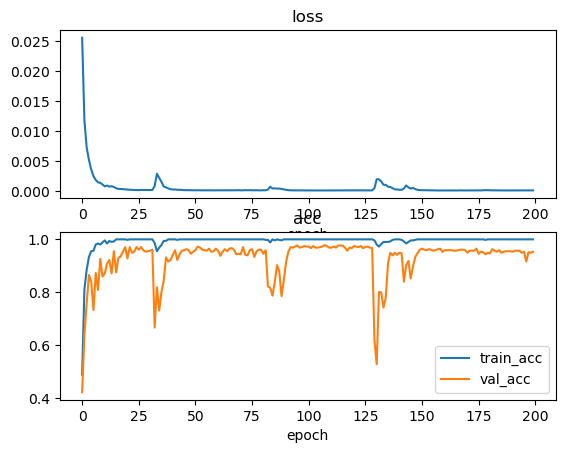

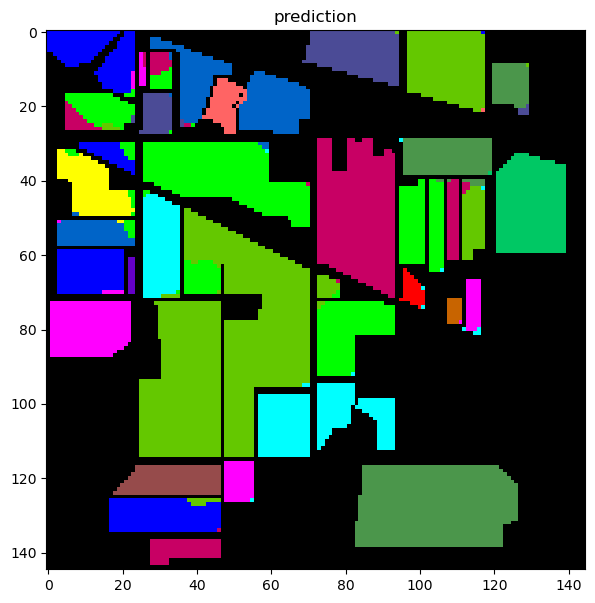

run 6 / 10
epoch 0/200 loss:0.026727070566266775  acc:0.490234375
epoch 0/200  val_acc:0.41796875
epoch 1/200 loss:0.012092029792256653  acc:0.765625
epoch 1/200  val_acc:0.58984375
epoch 2/200 loss:0.007371439191047102  acc:0.8828125
epoch 2/200  val_acc:0.595703125
epoch 3/200 loss:0.004906560236122459  acc:0.931640625
epoch 3/200  val_acc:0.732421875
epoch 4/200 loss:0.0037376094260253012  acc:0.9453125
epoch 4/200  val_acc:0.8046875
epoch 5/200 loss:0.00246243090077769  acc:0.966796875
epoch 5/200  val_acc:0.828125
epoch 6/200 loss:0.0017624906613491476  acc:0.978515625
epoch 6/200  val_acc:0.875
epoch 7/200 loss:0.0013293811280163936  acc:0.984375
epoch 7/200  val_acc:0.826171875
epoch 8/200 loss:0.0010044059381471016  acc:0.99609375
epoch 8/200  val_acc:0.87890625
epoch 9/200 loss:0.0006802591378800571  acc:0.998046875
epoch 9/200  val_acc:0.8828125
epoch 10/200 loss:0.0006534918829856906  acc:0.99609375
epoch 10/200  val_acc:0.927734375
epoch 11/200 loss:0.0004623357417585794  a

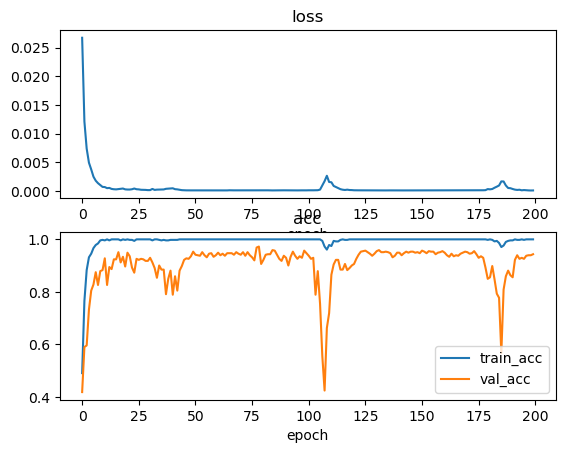

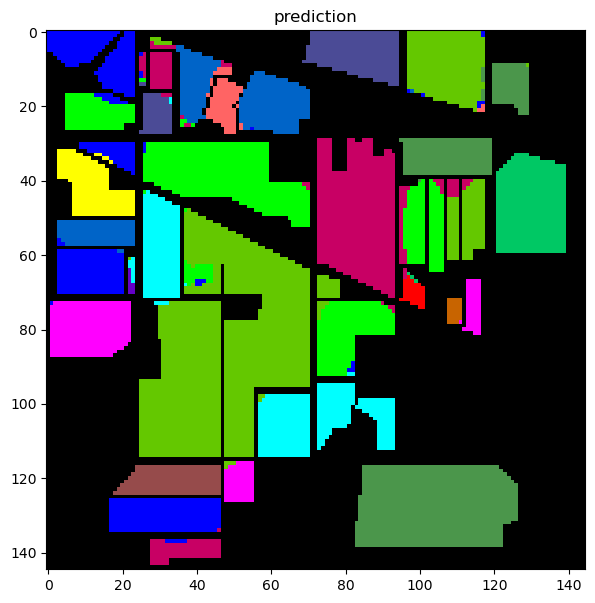

run 7 / 10
epoch 0/200 loss:0.025289646815508604  acc:0.5234375
epoch 0/200  val_acc:0.544921875
epoch 1/200 loss:0.012071693083271384  acc:0.767578125
epoch 1/200  val_acc:0.572265625
epoch 2/200 loss:0.007286000472959131  acc:0.88671875
epoch 2/200  val_acc:0.775390625
epoch 3/200 loss:0.004985811683582142  acc:0.919921875
epoch 3/200  val_acc:0.80078125
epoch 4/200 loss:0.0031555607565678656  acc:0.9453125
epoch 4/200  val_acc:0.892578125
epoch 5/200 loss:0.0021377156663220376  acc:0.974609375
epoch 5/200  val_acc:0.875
epoch 6/200 loss:0.0015022575971670449  acc:0.98828125
epoch 6/200  val_acc:0.90234375
epoch 7/200 loss:0.0012440749342204072  acc:0.98046875
epoch 7/200  val_acc:0.94921875
epoch 8/200 loss:0.0008524636104993988  acc:0.998046875
epoch 8/200  val_acc:0.841796875
epoch 9/200 loss:0.000736102658265736  acc:0.99609375
epoch 9/200  val_acc:0.8515625
epoch 10/200 loss:0.0008635574922664091  acc:0.98828125
epoch 10/200  val_acc:0.8125
epoch 11/200 loss:0.000998781601083465

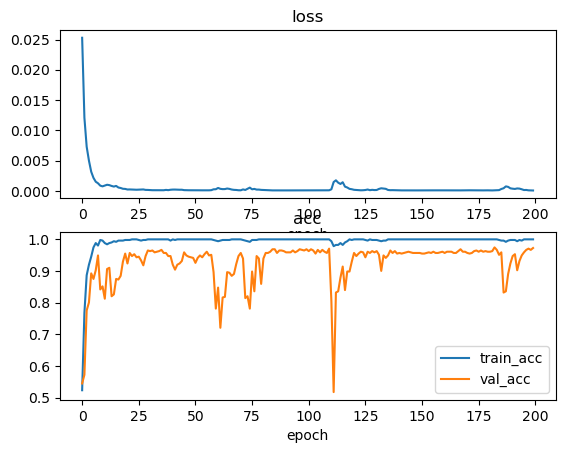

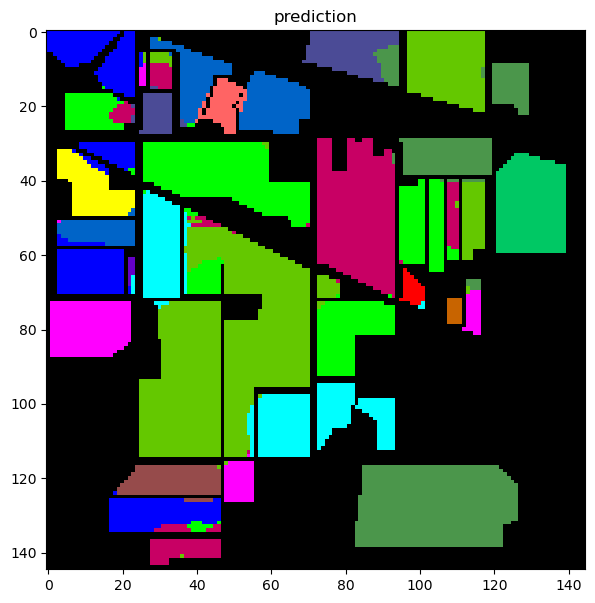

run 8 / 10
epoch 0/200 loss:0.02594021346885711  acc:0.515625
epoch 0/200  val_acc:0.443359375
epoch 1/200 loss:0.012141840416006744  acc:0.791015625
epoch 1/200  val_acc:0.68359375
epoch 2/200 loss:0.006940663733985275  acc:0.904296875
epoch 2/200  val_acc:0.7734375
epoch 3/200 loss:0.0042791314772330225  acc:0.94140625
epoch 3/200  val_acc:0.849609375
epoch 4/200 loss:0.002791148188407533  acc:0.966796875
epoch 4/200  val_acc:0.90625
epoch 5/200 loss:0.0016374757105950266  acc:0.9765625
epoch 5/200  val_acc:0.89453125
epoch 6/200 loss:0.0012199885677546263  acc:0.9921875
epoch 6/200  val_acc:0.912109375
epoch 7/200 loss:0.0012421617866493762  acc:0.98828125
epoch 7/200  val_acc:0.94921875
epoch 8/200 loss:0.0009842137078521773  acc:0.994140625
epoch 8/200  val_acc:0.88671875
epoch 9/200 loss:0.0007756514169159345  acc:0.998046875
epoch 9/200  val_acc:0.880859375
epoch 10/200 loss:0.0006662058185611386  acc:0.99609375
epoch 10/200  val_acc:0.94921875
epoch 11/200 loss:0.00055719369629

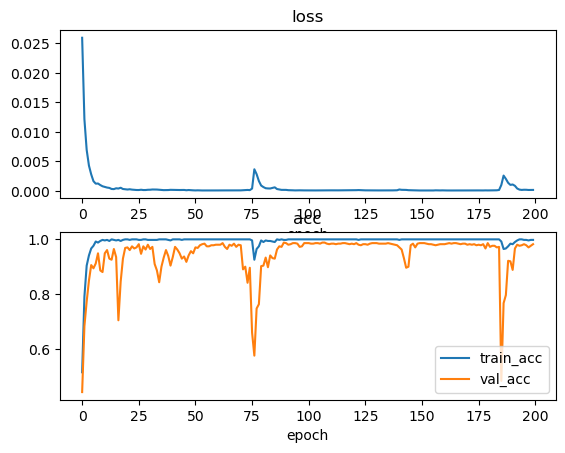

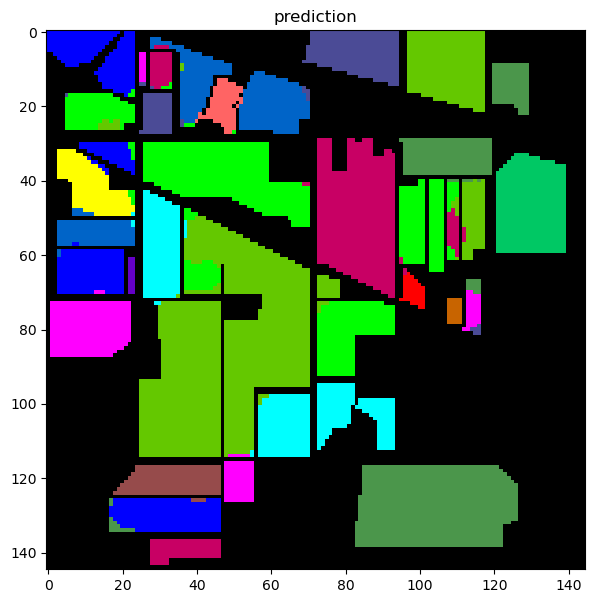

run 9 / 10
epoch 0/200 loss:0.02722457447089255  acc:0.470703125
epoch 0/200  val_acc:0.484375
epoch 1/200 loss:0.012548390193842351  acc:0.783203125
epoch 1/200  val_acc:0.7109375
epoch 2/200 loss:0.008202646393328905  acc:0.869140625
epoch 2/200  val_acc:0.755859375
epoch 3/200 loss:0.005350128310965374  acc:0.9140625
epoch 3/200  val_acc:0.80078125
epoch 4/200 loss:0.003773041215026751  acc:0.943359375
epoch 4/200  val_acc:0.87890625
epoch 5/200 loss:0.002938983408967033  acc:0.9609375
epoch 5/200  val_acc:0.8671875
epoch 6/200 loss:0.002019440129515715  acc:0.9765625
epoch 6/200  val_acc:0.7890625
epoch 7/200 loss:0.0013887530512874946  acc:0.984375
epoch 7/200  val_acc:0.841796875
epoch 8/200 loss:0.0012611903875949793  acc:0.984375
epoch 8/200  val_acc:0.912109375
epoch 9/200 loss:0.0009593057111487724  acc:0.9921875
epoch 9/200  val_acc:0.921875
epoch 10/200 loss:0.0008368263370357454  acc:0.9921875
epoch 10/200  val_acc:0.798828125
epoch 11/200 loss:0.0007357027134275995  acc:0

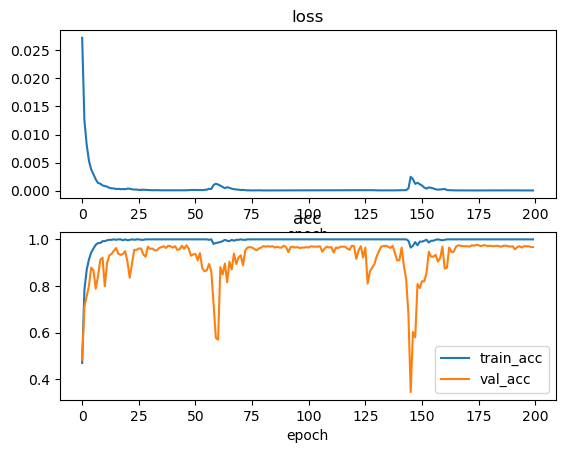

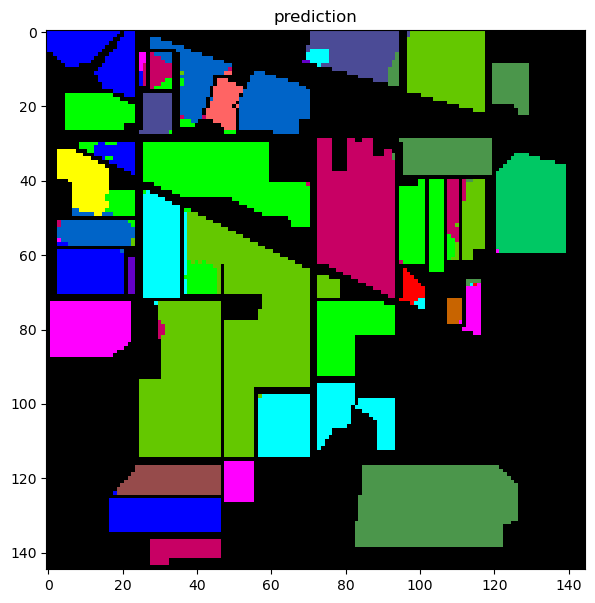

run 10 / 10
epoch 0/200 loss:0.025123506202362478  acc:0.525390625
epoch 0/200  val_acc:0.541015625
epoch 1/200 loss:0.011022204416804016  acc:0.802734375
epoch 1/200  val_acc:0.482421875
epoch 2/200 loss:0.006840665068011731  acc:0.875
epoch 2/200  val_acc:0.5390625
epoch 3/200 loss:0.004565219016512856  acc:0.931640625
epoch 3/200  val_acc:0.81640625
epoch 4/200 loss:0.0035041715018451214  acc:0.94921875
epoch 4/200  val_acc:0.724609375
epoch 5/200 loss:0.0026236265985062346  acc:0.970703125
epoch 5/200  val_acc:0.7734375
epoch 6/200 loss:0.001994413949432783  acc:0.97265625
epoch 6/200  val_acc:0.802734375
epoch 7/200 loss:0.0013475933301378973  acc:0.990234375
epoch 7/200  val_acc:0.875
epoch 8/200 loss:0.0010830915634869598  acc:0.98828125
epoch 8/200  val_acc:0.927734375
epoch 9/200 loss:0.0006537601002492011  acc:0.998046875
epoch 9/200  val_acc:0.90625
epoch 10/200 loss:0.0005636485584545881  acc:0.99609375
epoch 10/200  val_acc:0.92578125
epoch 11/200 loss:0.000469133086880901

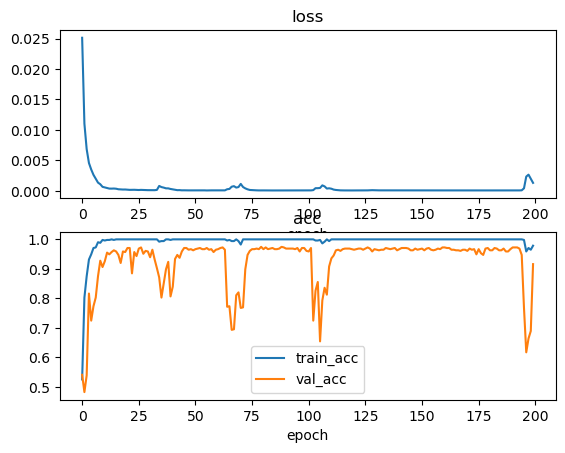

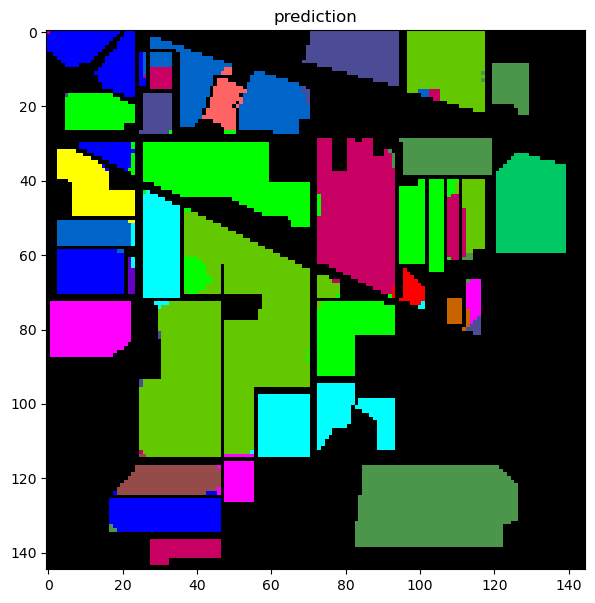


========== Final 10-run Results ==========
OA:       0.9723 ± 0.0049
AA:       0.9541 ± 0.0135
Kappa:    0.9684 ± 0.0056

Per-class accuracy:
Alfalfa: 0.8357 ± 0.1332
Corn-notill: 0.9597 ± 0.0210
Corn-mintill: 0.9643 ± 0.0292
Corn: 0.9268 ± 0.0773
Grass-pasture: 0.9572 ± 0.0171
Grass-trees: 0.9951 ± 0.0038
Grass-pasture-mowed: 0.9538 ± 0.0662
Hay-windrowed: 0.9995 ± 0.0009
Oats: 0.8722 ± 0.1877
Soybean-notill: 0.9587 ± 0.0134
Soybean-mintill: 0.9818 ± 0.0074
Soybean-clean: 0.9402 ± 0.0165
Wheat: 0.9859 ± 0.0166
Woods: 0.9977 ± 0.0030
Buildings-Grass-Trees-Drives: 0.9601 ± 0.0536
Stone-Steel-Towers: 0.9771 ± 0.0238



In [90]:
data,label,class_name = loadData(DATASET)
NUM_CLASS = label.max()

pca_data = applyPCA(data,N_PCA)
pca_data.shape

# random seeds for dataset splitting
seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
results = []
device = torch.device(DEVICE if DEVICE>=0 and torch.cuda.is_available() else 'cpu')

for run in range(10):
    np.random.seed(seeds[run])
    print("run {} / 10".format(run + 1))

    train_gt, test_gt = sample_gt(label,TRAIN_RATE, seeds[run])
    val_gt, test_gt = sample_gt(test_gt,VAL_RATE/(1-TRAIN_RATE), seeds[run])

    ## display sampling info
    if run == 0:
        sample_report = f"{'class': ^10}{'train_num':^10}{'val_num': ^10}{'test_num': ^10}{'total': ^10}\n"
        for i in np.unique(label):
            if i == 0: continue
            sample_report += f"{i: ^10}{(train_gt==i).sum(): ^10}{(val_gt==i).sum(): ^10}{(test_gt==i).sum(): ^10}{(label==i).sum(): ^10}\n"
        sample_report += f"{'total': ^10}{np.count_nonzero(train_gt): ^10}{np.count_nonzero(val_gt): ^10}{np.count_nonzero(test_gt): ^10}{np.count_nonzero(label): ^10}"
        print(sample_report)
    
    ## create dataset and dataloader
    train_data = PatchSet(data, pca_data, train_gt, PATCH_SIZE)
    val_data = PatchSet(data, pca_data, val_gt, PATCH_SIZE)
    all_data = PatchSet(data, pca_data, label, PATCH_SIZE,is_pred = True)
    train_loader = DataLoader(train_data,BATCH_SIZE,shuffle= True)
    val_loader = DataLoader(val_data,BATCH_SIZE,shuffle= True)
    all_loader = DataLoader(all_data,BATCH_SIZE,shuffle= False)

    d,d1,g=train_data.__getitem__(0)
    model = S3ViT(d.shape[0],PATCH_SIZE,class_nums=NUM_CLASS)

    ## display model info
    if run == 0:
        print(summary(model, input_size=[(1, d.shape[0], PATCH_SIZE, PATCH_SIZE), (1, N_PCA, PATCH_SIZE, PATCH_SIZE)],
                col_names=['num_params','kernel_size','mult_adds','input_size','output_size'],
                col_width=10, row_settings=['var_names'], depth=4))

    ## training the model
    val_acc_list, val_epoch_list = train(model, train_loader, val_loader, SAVE_PATH, device)

    ## load best model
    best_model_path = get_best_model(val_acc_list,val_epoch_list,SAVE_PATH)
    best_model = S3ViT(d.shape[0],PATCH_SIZE,class_nums=NUM_CLASS)
    best_model.load_state_dict(torch.load(best_model_path))

    ## inference
    test_pred, test_true = test(best_model, label, all_loader, test_gt, run+1, device)

    OA = accuracy_score(test_true,test_pred)
    AA = recall_score(test_true,test_pred,average='macro')
    kappa = cohen_kappa_score(test_true,test_pred)

    # accuracy of each class
    class_acc = recall_score(test_true, test_pred, average=None, labels=np.arange(1, NUM_CLASS + 1))

    # save results for final mean ± std
    results.append({"OA": OA, "AA": AA, "Kappa": kappa, "class_acc": class_acc})

    del model, best_model, train_data, train_loader, val_data, val_loader, all_data, all_loader

# final summary
oa_list = np.array([r["OA"] for r in results])
aa_list = np.array([r["AA"] for r in results])
kappa_list = np.array([r["Kappa"] for r in results])

class_acc_all = np.stack([r["class_acc"] for r in results], axis=0)
class_acc_mean = np.mean(class_acc_all, axis=0)
class_acc_std = np.std(class_acc_all, axis=0)

final_log = "\n========== Final 10-run Results ==========\n"
final_log += "OA:       {:.4f} ± {:.4f}\n".format(np.mean(oa_list), np.std(oa_list))
final_log += "AA:       {:.4f} ± {:.4f}\n".format(np.mean(aa_list), np.std(aa_list))
final_log += "Kappa:    {:.4f} ± {:.4f}\n".format(np.mean(kappa_list), np.std(kappa_list))

final_log += "\nPer-class accuracy:\n"
for name, mean_acc, std_acc in zip(class_name, class_acc_mean, class_acc_std):
    final_log += "{}: {:.4f} ± {:.4f}\n".format(name, mean_acc, std_acc)

print(final_log)
fp = open(os.path.join(SAVE_PATH, 'final_summary.txt'), 'w+')
fp.writelines(final_log)
fp.close()